<table width=100%>
<tr>
    <td><h1 style="text-align: left; font-size:250%;">
        Online Shoppers Purchasing Intention
    </h1></td>
    <td width="30%">
        <div style="text-align: right">
            <b>Machine Learning 2026</b><br>
            <b>Homework Project</b><br>
        </div>
    </td>
</tr>
</table>

**Name and surname:** _Giacomo Pogliana, Lorenzo Ponzone_  
**Student ID:** _308411,301776_

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

np.random.seed(0)

# Request 1 - Preliminary analysis and `ExitRates` regression

## 1.1 Data loading and first inspection

We load the provided training and test files. The first (unnamed) column is the index of the sample in the original dataset, so we use it as the DataFrame index.

In [2]:
# Read the data and create the pandas DataFrames
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv", index_col=0)
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv", index_col=0)

print("Training set shape:", train_data.shape)
print("Test set shape:    ", test_data.shape)

# Print the first few rows of the training set
train_data.head()

Training set shape: (9248, 18)
Test set shape:     (3082, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


In [3]:
# Check the data types of each column
train_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

The dataset contains:
* **10 numerical features**: `Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`, `ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`;
* **7 categorical features**: `Month` and `VisitorType` (strings), `Weekend` (boolean), and `OperatingSystems`, `Browser`, `Region`, `TrafficType`, which are *nominal* categories encoded with integer IDs (their numeric value has no ordinal meaning);
* the **binary target** `Revenue`.

## 1.2 Missing values

Here we inspect the dataset to check for the presence of missing values and quantify the missing values in both sets.

In [4]:
#Missing value calculation
print("Missing values - training set")
print(train_data.isna().sum())
print()
print("Missing values - test set")
print(test_data.isna().sum())

# Missing value percentage for ExitRates
print()
print("Missing value percentage")
missing_train_perc = 100 * train_data['ExitRates'].isna().mean()
missing_test_perc = 100 * test_data['ExitRates'].isna().mean()
print("ExitRates missing in training set:", missing_train_perc)
print("ExitRates missing in test set:", missing_test_perc)

Missing values - training set
Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

Missing values - test set
Administrative               0
Administrative_Duration      0
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  917
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSyst

`ExitRates` is the only corrupted variable: **~30% of the samples are missing in both sets** (2782 in train, 917 in test). All the other variables are complete.

Since the test set has the same corruption, any model comparison must be done using **only the training rows where `ExitRates` is known**.

## 1.3 Class distribution

Let's inspect how samples are distributed among the two classes of the target variable `Revenue`.

Class distribution for 'Revenue' - training set:
Revenue
False    7807
True     1441
Name: count, dtype: int64

Proportions:
Revenue
False    0.844183
True     0.155817
Name: proportion, dtype: float64

Class distribution for 'Revenue' - test set:
Revenue
False    2615
True      467
Name: count, dtype: int64

Proportions:
Revenue
False    0.848475
True     0.151525
Name: proportion, dtype: float64


<Axes: xlabel='Revenue', ylabel='count'>

Text(0.5, 1.0, 'Revenue distribution - training set')

<Axes: xlabel='Revenue', ylabel='count'>

Text(0.5, 1.0, 'Revenue distribution - test set')

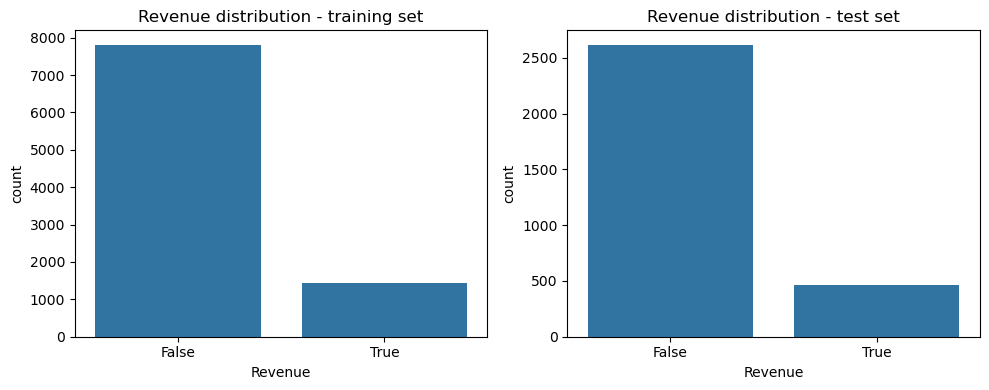

In [5]:
# Check the distribution of the target variable Revenue
print("Class distribution for 'Revenue' - training set:")
print(train_data['Revenue'].value_counts())
print("\nProportions:")
print(train_data['Revenue'].value_counts(normalize=True))

print("\nClass distribution for 'Revenue' - test set:")
print(test_data['Revenue'].value_counts())
print("\nProportions:")
print(test_data['Revenue'].value_counts(normalize=True))

# Bar plots for training and test set, side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=train_data, x='Revenue', ax=ax[0])
ax[0].set_title("Revenue distribution - training set")
sns.countplot(data=test_data, x='Revenue', ax=ax[1])
ax[1].set_title("Revenue distribution - test set")
plt.tight_layout()
plt.show()

The dataset is **strongly imbalanced**: only ~15% of the sessions end with a purchase, consistently in train and test.

## 1.4 Distribution of the numerical features

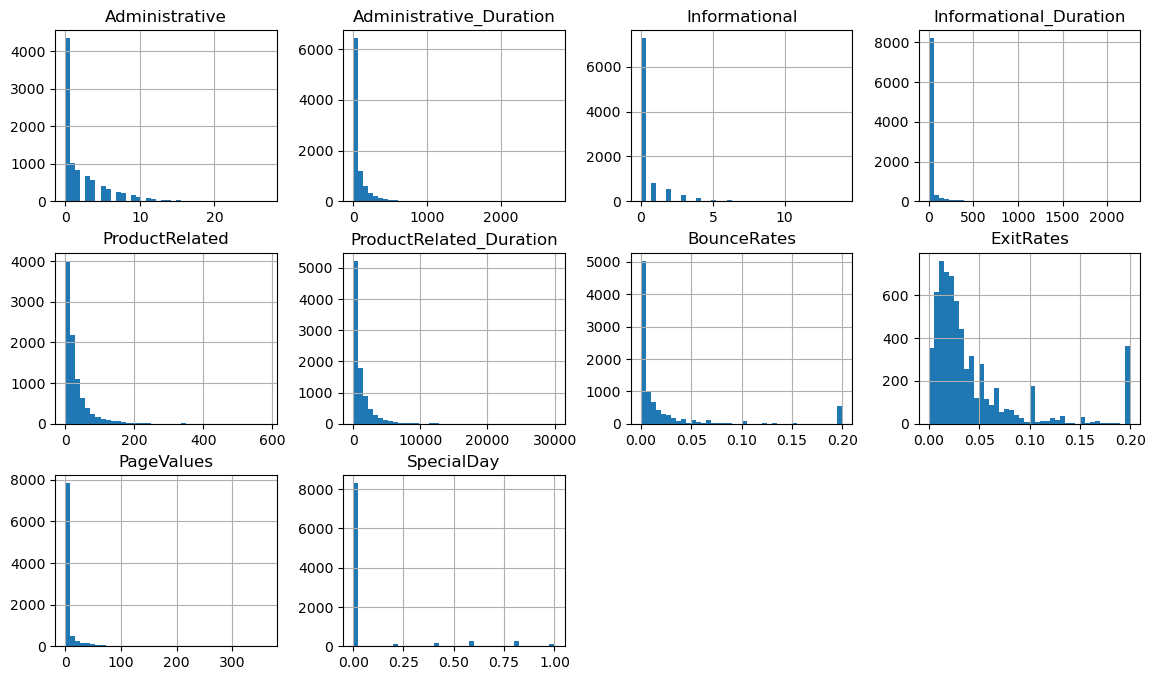

In [6]:
num_features = ["Administrative", "Administrative_Duration", "Informational",
                "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

# Histogram of each numerical feature
axes = train_data[num_features].hist(figsize=(14, 8), bins=40, layout=(3, 4))
plt.show()

In [7]:
# Summary statistics of the numerical features
train_data[num_features].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Administrative,9248.0,2.303,3.307,0.0,0.000,1.000,4.000,27.000
Administrative_Duration,9248.0,79.245,172.312,0.0,0.000,7.000,91.000,2720.500
Informational,9248.0,0.502,1.252,0.0,0.000,0.000,0.000,14.000
Informational_Duration,9248.0,34.904,140.234,0.0,0.000,0.000,0.000,2256.917
ProductRelated,9248.0,31.696,44.062,0.0,7.000,18.000,38.000,584.000
ProductRelated_Duration,9248.0,1183.553,1791.439,0.0,183.612,593.399,1456.401,29970.466
BounceRates,9248.0,0.023,0.049,0.0,0.000,0.003,0.017,0.200
ExitRates,6466.0,0.043,0.048,0.0,0.014,0.025,0.050,0.200
PageValues,9248.0,5.841,18.448,0.0,0.000,0.000,0.000,361.764
SpecialDay,9248.0,0.063,0.200,0.0,0.000,0.000,0.000,1.000


All the page-count and duration features are **heavily right-skewed**: most sessions visit few pages and last a short time, with a long tail of very long sessions. `PageValues` is zero for the vast majority of sessions, and `SpecialDay` is different from zero only for a small subset of visits. `BounceRates` and `ExitRates` are rates bounded in $[0, 0.2]$, with large spikes at the boundary values: many sessions have `BounceRates` $= 0$ (the user did not leave immediately) and a group of sessions has `BounceRates` $=$ `ExitRates` $= 0.2$ (typically single-page sessions).

Since we will use distance-based models (e.g., KNN, SVM, clustering), features with such different scales must be **standardized** before modeling, with `StandardScaler` on the training data and apply the same transformation to the test data.

## 1.5 Correlation analysis

We compute the Pearson correlation matrix between the numerical variables and the target, to identify (a) correlated features and (b) the features most related to `Revenue` and to `ExitRates`.

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Feature Correlation Matrix Train data')

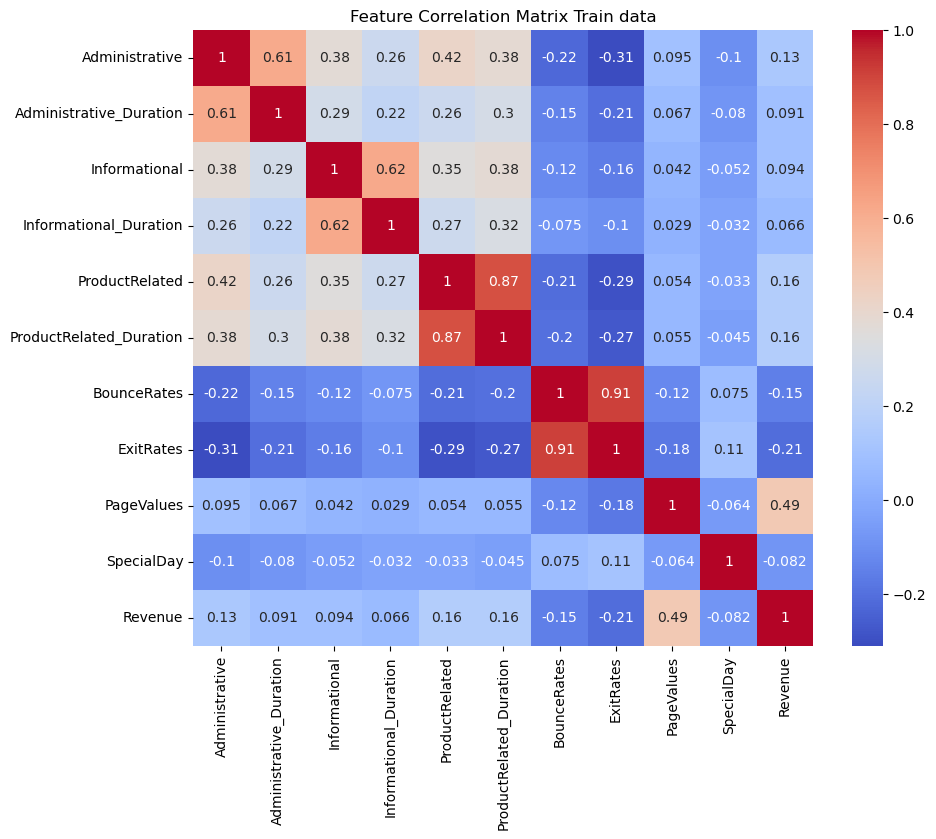

In [8]:
# Correlation matrix of numerical features + target
corr = train_data[num_features + ["Revenue"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix Train data")
plt.show()

In [9]:
# Features most correlated with Revenue
print("Correlation with Revenue:")
corr["Revenue"].drop("Revenue").round(2).sort_values(key=abs, ascending=False)

Correlation with Revenue:


PageValues                 0.49
ExitRates                 -0.21
ProductRelated_Duration    0.16
ProductRelated             0.16
BounceRates               -0.15
Administrative             0.13
Administrative_Duration    0.09
Informational              0.09
SpecialDay                -0.08
Informational_Duration     0.07
Name: Revenue, dtype: float64

In [10]:
# Features most correlated with Exit rates
print("Correlation with ExitRates:")
corr["ExitRates"].drop("ExitRates").round(2).sort_values(key=abs, ascending=False)

Correlation with ExitRates:


BounceRates                0.91
Administrative            -0.31
ProductRelated            -0.29
ProductRelated_Duration   -0.27
Administrative_Duration   -0.21
Revenue                   -0.21
PageValues                -0.18
Informational             -0.16
SpecialDay                 0.11
Informational_Duration    -0.10
Name: ExitRates, dtype: float64

* **`PageValues` is by far the feature most correlated with `Revenue`** (≈0.49): sessions that visited pages with high "value" are much more likely to end with a purchase. `ExitRates` and `BounceRates` are *negatively* correlated with the target (≈-0.2 / -0.15): sessions with high exit/bounce rates rarely convert.
* **`BounceRates` and `ExitRates` are extremely correlated with each other (≈0.91)**: this is excellent news for the regression task, since `BounceRates` alone already explains most of the variance of `ExitRates`. `ExitRates` is also mildly (negatively) correlated with the page-count features (`ProductRelated`, `Administrative`, ...): users who visit many pages tend to have lower exit rates.
* The pairs (`Administrative`, `Administrative_Duration`), (`Informational`, `Informational_Duration`) and especially (`ProductRelated`, `ProductRelated_Duration`) are strongly correlated (0.6-0.87), as expected: visiting more pages of a section implies spending more time on it. This redundancy is a good motivation for **feature selection**..

## 1.6 Preprocessing

We now build the encoded version of the datasets:
* `Weekend` and `Revenue` are cast from boolean to $\{0,1\}$;
* `Month` and `VisitorType` are **one-hot encoded** with `pd.get_dummies` (they are nominal strings);
* train and test columns are aligned to guarantee the same feature space.

In [11]:
def preprocess(df):
    """Encode booleans and one-hot encode the nominal features"""
    out = df.copy()
    out["Weekend"] = out["Weekend"].astype(int)
    out["Revenue"] = out["Revenue"].astype(int)
    out = pd.get_dummies(out, columns=["Month", "VisitorType", "OperatingSystems",
                                       "Browser", "Region", "TrafficType"], dtype=int, drop_first=True)
    return out

train_enc = preprocess(train_data)
test_enc = preprocess(test_data)

# Align the test columns to the training ones: dummies of levels seen only
# in training are added to the test set with value 0; selecting the train
# columns also drops the dummies of levels never seen in training (Browser 9)
for col in train_enc.columns:
    if col not in test_enc.columns:
        test_enc[col] = 0
test_enc = test_enc[train_enc.columns]

print("Same columns in train and test:", (train_enc.columns == test_enc.columns).all())
print("Encoded training set shape:", train_enc.shape)
print("Encoded test set shape:    ", test_enc.shape)
train_enc.head(3)
test_enc.head(3)

Same columns in train and test: True
Encoded training set shape: (9248, 68)
Encoded test set shape:     (3082, 68)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,...,0,0,0,0,0,0,0,0,0,0
9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,...,0,0,0,0,0,0,0,0,0,0
9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,...,0,0,0,0,0,0,0,0,0,0


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## 1.7 Regression of `ExitRates`

We now train a regressor to predict `ExitRates` from the remaining variables. Following the homework instructions:

* we use **only the training set** (the ~6.5k samples where `ExitRates` is observed);
* the models are compared with **5-fold cross-validation**, using the **$R^2$** score as metric;
* every model is wrapped in a `Pipeline` with a `StandardScaler`, so that the scaling is fit on each training fold only (no leakage into the validation folds).

We **exclude `Revenue` from the regressors' inputs**: even if it is available in both files, using the classification target to impute a feature would inject information about `Revenue` into `ExitRates`, biasing the comparison "with vs without `ExitRates`" required in Request 2.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score

# Samples of the training set where ExitRates is observed
missing_exit_rates = train_enc['ExitRates'].isna()
reg_data = train_enc[train_enc["ExitRates"].notna()]
X_reg = reg_data.drop(columns=["ExitRates", "Revenue"])
y_reg = reg_data["ExitRates"]

print("Samples available before:", train_enc.shape[0])
print("Samples available for the regression task:", X_reg.shape[0])
print("Number of features:", X_reg.shape[1])
print("Number of missing ExitRates to be predicted later:", missing_exit_rates.sum())

Samples available before: 9248
Samples available for the regression task: 6466
Number of features: 66
Number of missing ExitRates to be predicted later: 2782


In [13]:
# Linear Regression (no hyperparameters): 5-fold cross-validation.
lin_reg = Pipeline([("scaler", StandardScaler()),
                    ("model", LinearRegression())])
scores = cross_val_score(lin_reg, X_reg, y_reg, cv=5, scoring="r2", n_jobs=-1)
print("Linear Regression: CV R2 = {:.4f} +/- {:.4f}".format(scores.mean(), scores.std()))

cv_r2 = {"Linear Regression": scores.mean()}

Linear Regression: CV R2 = 0.8597 +/- 0.0159


In [14]:
# Ridge regression
ridge_cv = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), 
              ("model", Ridge())]),
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="r2", n_jobs=-1)
ridge_cv.fit(X_reg, y_reg)
print("Best parameters:", ridge_cv.best_params_)
print("Ridge: best CV R2 = {:.4f}".format(ridge_cv.best_score_))
cv_r2["Ridge"] = ridge_cv.best_score_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

Best parameters: {'model__alpha': 10}
Ridge: best CV R2 = 0.8597


In [15]:
# Lasso regression
lasso_cv = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))]),
    {"model__alpha": [1e-5, 1e-4, 1e-3, 1e-2]},
    cv=5, scoring="r2", n_jobs=-1)
lasso_cv.fit(X_reg, y_reg)
print("Best parameters:", lasso_cv.best_params_)
print("Lasso: best CV R2 = {:.4f}".format(lasso_cv.best_score_))
cv_r2["Lasso"] = lasso_cv.best_score_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Lasso(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'model__alpha': [1e-05, 0.0001, 0.001, 0.01]},
             scoring='r2')

Best parameters: {'model__alpha': 0.0001}
Lasso: best CV R2 = 0.8602


In [16]:
# Polynomial regression: the degree is a hyperparameter, optimized by GridSearchCV. With 72 encoded features, 
# degree 2 already produces ~2700 columns and degree 3 would generate more columns than the available samples, 
# so the grid stops at 2

poly_cv = GridSearchCV(
    Pipeline([("poly", PolynomialFeatures(include_bias=False)),
              ("scaler", StandardScaler()),
              ("model", LinearRegression())]),
    {"poly__degree": [1, 2]},
    cv=5, scoring="r2", n_jobs=-1)
poly_cv.fit(X_reg, y_reg)
print("Best parameters:", poly_cv.best_params_)
print("Polynomial: best CV R2 = {:.4f}".format(poly_cv.best_score_))
cv_r2["Polynomial"] = poly_cv.best_score_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model', LinearRegression())]),
             n_jobs=-1, param_grid={'poly__degree': [1, 2]}, scoring='r2')

Best parameters: {'poly__degree': 1}
Polynomial: best CV R2 = 0.8597


In [17]:
# Summary of the cross-validated R2 of the compared algorithms
pd.DataFrame({"CV R2": cv_r2}).round(4)

,CV R2
Linear Regression,0.8597
Ridge,0.8597
Lasso,0.8602
Polynomial,0.8597


All the linear models are statistically equivalent (0.8603–0.8608, differences an order of magnitude below the fold-to-fold standard deviation of the CV estimate, ≈ ±0.015). The polynomial model selects degree 1 by cross-validation, so it collapses to plain linear regression: the relationship between the features and `ExitRates` appears linear on the full feature set. Since all models are equivalent, we use the simplest and fastest one, Linear Regression, as the evaluator inside the forward selection below.

In [18]:
from sklearn.feature_selection import SequentialFeatureSelector

def run_forward_selection(X, y, model, max_features, cv=5):
    """Wrapper around sklearn's SequentialFeatureSelector: for each subset
    size from 1 to max_features, run a forward search and record its
    cross-validated R2."""
    history = []
    for k in range(1, max_features + 1):
        sfs = SequentialFeatureSelector(model, n_features_to_select=k,
                                        direction="forward",
                                        scoring="r2", cv=cv, n_jobs=-1)
        sfs.fit(X, y)
        selected = X.columns[sfs.get_support()].tolist()
        score = cross_val_score(model, X[selected], y, cv=cv,
                                scoring="r2", n_jobs=-1).mean()
        history.append([k, selected, score])
        print("k={:2d}: CV R2 = {:.4f}  ->  {}".format(k, score, selected))
    return pd.DataFrame(history, columns=["n_features", "features", "cv_score"])

fs_history = run_forward_selection(X_reg, y_reg, LinearRegression(), max_features=20)

k= 1: CV R2 = 0.8320  ->  ['BounceRates']
k= 2: CV R2 = 0.8445  ->  ['Administrative', 'BounceRates']
k= 3: CV R2 = 0.8496  ->  ['Administrative', 'ProductRelated', 'BounceRates']
k= 4: CV R2 = 0.8543  ->  ['Administrative', 'ProductRelated', 'BounceRates', 'VisitorType_Returning_Visitor']
k= 5: CV R2 = 0.8570  ->  ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'VisitorType_Returning_Visitor']
k= 6: CV R2 = 0.8582  ->  ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'VisitorType_Returning_Visitor', 'TrafficType_2']
k= 7: CV R2 = 0.8592  ->  ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'VisitorType_Returning_Visitor', 'OperatingSystems_2', 'TrafficType_2']
k= 8: CV R2 = 0.8596  ->  ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'SpecialDay', 'VisitorType_Returning_Visitor', 'OperatingSystems_2', 'TrafficType_2']
k= 9: CV R2 = 0.8600  ->  ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'Special

Text(0.5, 0, 'number of selected features')

Text(0, 0.5, 'cv($R^2$)')

Text(0.5, 1.0, 'Forward selection - CV R2 per subset size')

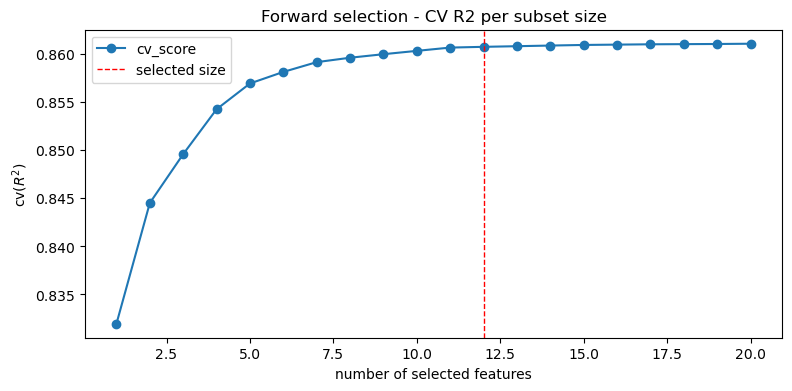

In [19]:
ax = fs_history.plot(x="n_features", y="cv_score", marker="o", figsize=(9, 4), legend=False)
ax.set_xlabel("number of selected features"); ax.set_ylabel("cv($R^2$)")
ax.set_title("Forward selection - CV R2 per subset size")
ax.axvline(12, color="red", ls="--", lw=1, label="selected size")
ax.legend()
plt.show()

In [20]:
n_selected = 12  # chosen by inspection: the curve is already nearly flat here
selected_features = fs_history["features"].iloc[n_selected - 1]
print("Selected {} features (cv(R2) = {:.4f}, vs {:.4f} at the maximum):".format(
    n_selected, fs_history["cv_score"].iloc[n_selected - 1], fs_history["cv_score"].max()))
print(selected_features)

Selected 12 features (cv(R2) = 0.8608, vs 0.8611 at the maximum):
['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'SpecialDay', 'Month_June', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'OperatingSystems_2', 'TrafficType_2', 'TrafficType_4', 'TrafficType_19']


We select 12 features by inspecting the curve above: the cross-validated R² becomes essentially flat from this point onward (0.8613 at k = 12 vs 0.8617 at the maximum, k = 20, a difference of 0.0004). The features added after this point are mostly single rare levels of high-cardinality attributes (`specific Browser`, `Region` or `TrafficType codes`), which contribute noise rather than signal. Note that `BounceRates` enters first with R² ≈ 0.83 alone, as anticipated by its 0.91 correlation with `ExitRates` in the EDA.

With the optimal subset of 12 features defined, we now proceed to retrain and evaluate our regression models restricted to this reduced feature space.

In [21]:
X_reg_sel = X_reg[selected_features]

# Linear Regression on the selected features
lin_sel = Pipeline([("scaler", StandardScaler()), 
                    ("model", LinearRegression())])
scores = cross_val_score(lin_sel, X_reg_sel, y_reg, cv=5, scoring="r2", n_jobs=-1)
print("Linear (selected):  CV R2 = {:.4f} +/- {:.4f}".format(scores.mean(), scores.std()))

cv_r2["Linear Regression selected"] = scores.mean()

Linear (selected):  CV R2 = 0.8608 +/- 0.0155


In [22]:
# Ridge Regression on the selected features

ridge_sel = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
    {"model__alpha": [0.01, 0.1, 1, 10, 100]}, cv=5, scoring="r2", n_jobs=-1)
ridge_sel.fit(X_reg_sel, y_reg)
print("Best parameters:", ridge_sel.best_params_)
print("Ridge (selected): best CV R2 = {:.4f}".format(ridge_sel.best_score_))
cv_r2["Ridge selected"] = ridge_sel.best_score_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             n_jobs=-1, param_grid={'model__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

Best parameters: {'model__alpha': 0.01}
Ridge (selected): best CV R2 = 0.8608


In [23]:
# Lasso regression on the selected features
lasso_sel = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter=10000))]),
    {"model__alpha": [1e-5, 1e-4, 1e-3, 1e-2]},
    cv=5, scoring="r2", n_jobs=-1)
lasso_sel.fit(X_reg_sel, y_reg)
print("Best parameters:", lasso_sel.best_params_)
print("Lasso: best CV R2 = {:.4f}".format(lasso_sel.best_score_))
cv_r2["Lasso selected"] = lasso_sel.best_score_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Lasso(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'model__alpha': [1e-05, 0.0001, 0.001, 0.01]},
             scoring='r2')

Best parameters: {'model__alpha': 1e-05}
Lasso: best CV R2 = 0.8608


In [24]:
# Polynomial Regression on the selected features

poly_sel = GridSearchCV(
    Pipeline([("poly", PolynomialFeatures(include_bias=False)),
              ("scaler", StandardScaler()),
              ("model", LinearRegression())]),
    {"poly__degree": [1, 2, 3]},
    cv=5, scoring="r2", n_jobs=-1)
poly_sel.fit(X_reg_sel, y_reg)
print("Best parameters:", poly_sel.best_params_)
print("Polynomial: best CV R2 = {:.4f}".format(poly_sel.best_score_))
cv_r2["Polynomial selected"] = poly_sel.best_score_

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model', LinearRegression())]),
             n_jobs=-1, param_grid={'poly__degree': [1, 2, 3]}, scoring='r2')

Best parameters: {'poly__degree': 2}
Polynomial: best CV R2 = 0.8711


,CV R2
Linear Regression,0.8597
Ridge,0.8597
Lasso,0.8602
Polynomial,0.8597
Linear Regression selected,0.8608
Ridge selected,0.8608
Lasso selected,0.8608
Polynomial selected,0.8711


Text(0, 0.5, 'R2-score (5-fold CV)')

Text(0.5, 1.0, 'Regression algorithms - cross-validated R2')

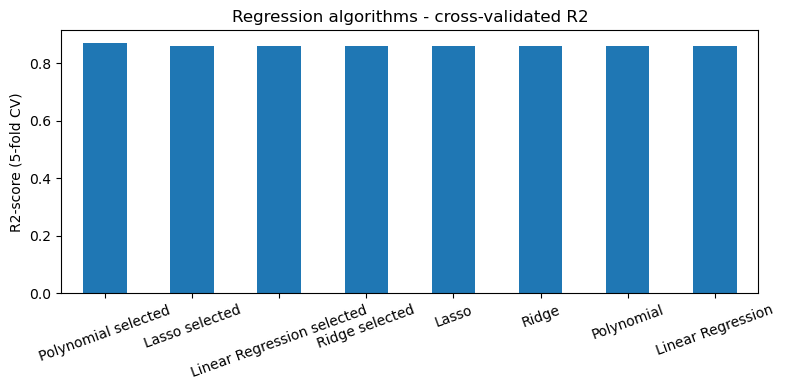

Text(0, 0.5, '$R^2$ (5-fold CV)')

Text(0.5, 1.0, 'Regression algorithms - cross-validated $R^2$')

(0.8, 0.9)

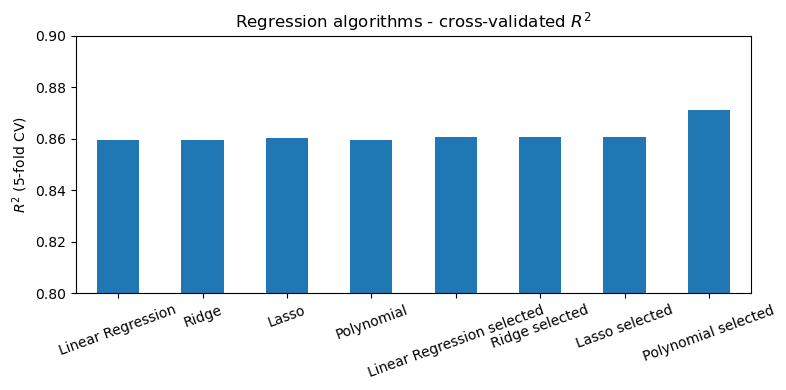

Linear Regression             0.8597
Ridge                         0.8597
Lasso                         0.8602
Polynomial                    0.8597
Linear Regression selected    0.8608
Ridge selected                0.8608
Lasso selected                0.8608
Polynomial selected           0.8711
Name: CV R2, dtype: float64

In [25]:
# Summary of the cross-validated R2
pd.DataFrame({"CV R2": cv_r2}).round(4)

# Visual comparison of the cross-validated R2 of the algorithms
ax = pd.Series(cv_r2).sort_values(ascending=False).plot.bar(figsize=(8, 4), rot=20)
ax.set_ylabel("R2-score (5-fold CV)")
ax.set_title("Regression algorithms - cross-validated R2")
plt.tight_layout()
plt.show()

# Visual comparison of the cross-validated R2 of the algorithms
ax = pd.Series(cv_r2).plot.bar(figsize=(8, 4), rot=20)
ax.set_ylabel("$R^2$ (5-fold CV)")
ax.set_title("Regression algorithms - cross-validated $R^2$")
ax.set_ylim(0.80, 0.9)
plt.tight_layout()
plt.show()
pd.Series(cv_r2, name="CV R2").round(4)

On the 12 selected features the linear models are again equivalent. The degree-2 polynomial, instead, clearly benefits from the selection: it reaches 0.8711, the best score of the whole comparison. The gain over the linear model (+0.013) is modest, suggesting genuine mild non-linearity. So we choose the model Polynomial selected as final regressor.

In [26]:
# This is the final regressor.

final_regressor = GridSearchCV(
    Pipeline([("poly", PolynomialFeatures(include_bias=False)),
              ("scaler", StandardScaler()),
              ("model", LinearRegression())]),
    {"poly__degree": [1, 2, 3]},
    cv=5, scoring="r2", n_jobs=-1)
final_regressor.fit(X_reg_sel, y_reg)
print("Final regressor trained on", len(selected_features), "features:", selected_features)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('model', LinearRegression())]),
             n_jobs=-1, param_grid={'poly__degree': [1, 2, 3]}, scoring='r2')

Final regressor trained on 12 features: ['Administrative', 'ProductRelated', 'BounceRates', 'PageValues', 'SpecialDay', 'Month_June', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'OperatingSystems_2', 'TrafficType_2', 'TrafficType_4', 'TrafficType_19']


### Summary of Request 1. 
In conclusion, our exploratory analysis highlighted a strongly imbalanced target (~15% purchases) and heavily right-skewed behavioral features. Notably, the strong correlation between `BounceRates` and `ExitRates` (r ≈ 0.91) provided a solid foundation for the regression task. While standard linear models achieved a CV R² of ~0.86 on the full dataset, Forward Selection allowed us to shrink the feature space to just 12 variables without losing predictive power. On this reduced subset, a degree-2 Polynomial Regression emerged as the best model (CV R² = 0.8711) and was selected as our final imputer.

As a methodological note, `Revenue` was strictly excluded from the regression inputs to prevent data leakage, ensuring a fair 'with vs. without ExitRates' comparison in the next classification step. Finally, to guarantee a robust evaluation, all models were trained and validated exclusively on the training data using 5-fold cross-validation.

# Request 2 - `ExitRates` imputation and `Revenue` classification

## 2.1 Recovering `ExitRates` on train and test set

We use the regressor trained in Request 1 to predict the missing `ExitRates` values on both sets. Note that the model was trained **only on training data**, so no information leaks from the test set.

In [27]:
# Predict the missing ExitRates values on the TRAINING set
train_imp = train_enc.copy()
mask_train = train_imp["ExitRates"].isna()
pred_train = final_regressor.predict(train_imp.loc[mask_train, selected_features])
# ExitRates is a rate in [0, 0.2]: clip the predictions to the valid range
train_imp.loc[mask_train, "ExitRates"] = np.clip(pred_train, 0, 0.2)

# Predict the missing ExitRates values on the TEST set
test_imp = test_enc.copy()
mask_test = test_imp["ExitRates"].isna()
pred_test = final_regressor.predict(test_imp.loc[mask_test, selected_features])
test_imp.loc[mask_test, "ExitRates"] = np.clip(pred_test, 0, 0.2)

print("Imputed values in train:", mask_train.sum())
print("Imputed values in test: ", mask_test.sum())
print("Remaining NaNs:", train_imp.isna().sum().sum() + test_imp.isna().sum().sum())

Imputed values in train: 2782
Imputed values in test:  917
Remaining NaNs: 0


## 2.2 Setup of the classification task

We now predict `Revenue`. Given the class imbalance observed in the EDA (~15% positives):

* models are compared with **5-fold cross-validation** using the **F1-score of the positive class** as the model-selection metric (accuracy would favor trivial classifiers). Note that for classification problems `cross_val_score` and `GridSearchCV` automatically use *stratified* folds, so each fold preserves the class proportions;
* the hyperparameter grids include the `class_weight` option where available, which reweights the classes during training;
* all the models are `Pipeline`s with a `StandardScaler` in front.

The test set is used **only once, at the very end**, to evaluate the selected model.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)

X_train = train_imp.drop(columns=["Revenue"])
y_train = train_imp["Revenue"]
X_test = test_imp.drop(columns=["Revenue"])
y_test = test_imp["Revenue"]

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (9248, 67)  X_test: (3082, 67)


## 2.3 Feature selection

We repeat the forward selection strategy, this time maximizing the cross-validated **F1-score** of a Logistic Regression classifier (with `class_weight='balanced'` to cope with the imbalance). To keep the computation feasible we use 5-fold CV inside the evaluator and stop at 20 features.

In [29]:
# Forward selection for classification(F1 as metric, balanced Logistic Regression as model)
clf_evaluator = Pipeline([("scaler", StandardScaler()),
                          ("model", LogisticRegression(max_iter=1000,
                                                       class_weight="balanced"))])

def run_forward_selection_clf(X, y, model, max_features, cv=5):
    history = []
    for k in range(1, max_features + 1):
        sfs = SequentialFeatureSelector(model, n_features_to_select=k,
                                        direction="forward",
                                        scoring="f1", cv=cv, n_jobs=-1)
        sfs.fit(X, y)
        selected = X.columns[sfs.get_support()].tolist()
        score = cross_val_score(model, X[selected], y, cv=5,
                                scoring="f1", n_jobs=-1).mean()
        history.append([k, selected, score])
        print("k={:2d}: CV F1 = {:.4f}  ->  {}".format(k, score, selected))
    return pd.DataFrame(history, columns=["n_features", "features", "cv_score"])

fs_clf = run_forward_selection_clf(X_train, y_train, clf_evaluator, max_features=20)

k= 1: CV F1 = 0.6452  ->  ['PageValues']
k= 2: CV F1 = 0.6665  ->  ['PageValues', 'Month_Nov']
k= 3: CV F1 = 0.6674  ->  ['PageValues', 'Month_Nov', 'Browser_3']
k= 4: CV F1 = 0.6681  ->  ['PageValues', 'Month_Nov', 'Browser_3', 'Region_5']
k= 5: CV F1 = 0.6681  ->  ['PageValues', 'Month_Nov', 'Browser_3', 'Region_5', 'TrafficType_12']
k= 6: CV F1 = 0.6681  ->  ['PageValues', 'Month_Nov', 'Browser_3', 'Region_5', 'TrafficType_12', 'TrafficType_16']
k= 7: CV F1 = 0.6681  ->  ['PageValues', 'Month_Nov', 'Browser_3', 'Region_5', 'TrafficType_12', 'TrafficType_16', 'TrafficType_17']
k= 8: CV F1 = 0.6681  ->  ['PageValues', 'Month_Nov', 'Browser_3', 'Browser_7', 'Region_5', 'TrafficType_12', 'TrafficType_16', 'TrafficType_17']
k= 9: CV F1 = 0.6683  ->  ['PageValues', 'Month_Dec', 'Month_Nov', 'Browser_3', 'Browser_7', 'Region_5', 'TrafficType_12', 'TrafficType_16', 'TrafficType_17']
k=10: CV F1 = 0.6683  ->  ['PageValues', 'Month_Dec', 'Month_Nov', 'Browser_3', 'Browser_7', 'Browser_13', 'R

Text(0.5, 0, 'number of selected features')

Text(0, 0.5, 'F1-score (5-fold CV)')

Text(0.5, 1.0, 'Forward selection - Logistic Regression (balanced)')

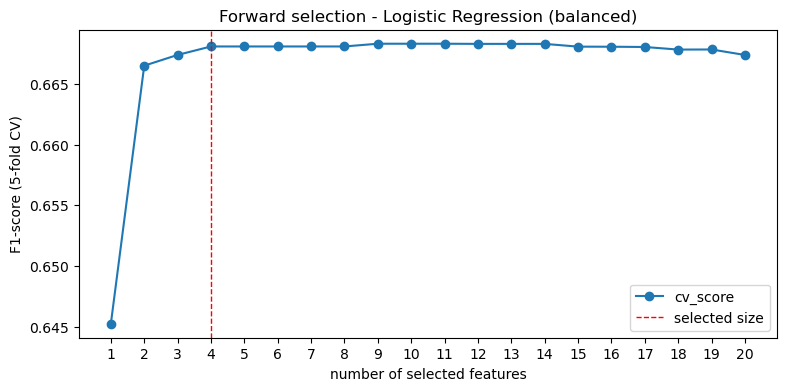

In [30]:
ax = fs_clf.plot(x="n_features", y="cv_score", marker="o", figsize=(9, 4), legend=False)
ax.set_xlabel("number of selected features")
ax.set_ylabel("F1-score (5-fold CV)")
ax.set_title("Forward selection - Logistic Regression (balanced)")
ax.set_xticks(fs_clf["n_features"].to_numpy())
ax.axvline(4, color="red", ls="--", lw=1, label="selected size")
ax.legend()
plt.show()

In [31]:
n_selected_class = 4  # chosen by inspection: the curve is already flat here
selected_clf_features = fs_clf["features"].iloc[n_selected_class - 1]
print("Selected {} features (CV F1 = {:.4f}):".format(n_selected_class, fs_clf["cv_score"].iloc[n_selected_class - 1]))
print(selected_clf_features)

Selected 4 features (CV F1 = 0.6681):
['PageValues', 'Month_Nov', 'Browser_3', 'Region_5']


`PageValues` alone already reaches F1 ≈ 0.645, so is by far the dominant predictor, as anticipated by its correlation with Revenue in the EDA. From k = 3 onward the curve is essentially flat: the added features (`Browser_3`, `Region_5`, then single rare `TrafficType levels`) contribute less than 0.002 each, indistinguishable from noise. We keep 4 features as a small margin past the elbow. Interestingly, neither `ExitRates` nor `BounceRates` is ever selected: once `PageValues` and the seasonality are known, the exit-rate information appears redundant for predicting the purchase.

## 2.4 Model comparison

We compare the classifiers **Logistic Regression, KNN, LDA, QDA and SVM (RBF kernel)** on the selected features and report the best cross-validated score.

In [32]:
#data preparation
X_train_sel = X_train[selected_clf_features]
X_test_sel = X_test[selected_clf_features]

print("New dimension X_train:", X_train_sel.shape)
print("New dimension X_test:", X_test_sel.shape)

New dimension X_train: (9248, 4)
New dimension X_test: (3082, 4)


In [33]:
# Logistic Regression: tune the regularization strength C and class_weight
log_cv = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter=1000))]),
    {"model__C": [0.01, 0.1, 1, 10],
     "model__class_weight": [None, "balanced"]},
    cv=5, scoring="f1", n_jobs=-1)
log_cv.fit(X_train_sel, y_train)
print("Best parameters:", log_cv.best_params_)
print("Logistic Regression: best CV F1 = {:.4f}".format(log_cv.best_score_))

# We collect the CV score of each algorithm for the final comparison
cv_f1 = {"Logistic Regression": log_cv.best_score_}

# We also collect the CV AUC
scores_log = cross_val_score(log_cv.best_estimator_, X_train_sel, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
cv_auc = {"Logistic Regression": scores_log.mean()}
print("Logistic Regression: CV AUC = {:.4f}".format(scores_log.mean()))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__class_weight': [None, 'balanced']},
             scoring='f1')

Best parameters: {'model__C': 1, 'model__class_weight': 'balanced'}
Logistic Regression: best CV F1 = 0.6681
Logistic Regression: CV AUC = 0.8866


In [34]:
# KNN: tune the number of neighbors
knnc_cv = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("model", KNeighborsClassifier())]),
    {"model__n_neighbors": [5, 11, 15, 19, 21, 25, 31]},
    cv=5, scoring="f1", n_jobs=-1)
knnc_cv.fit(X_train_sel, y_train)
print("Best parameters:", knnc_cv.best_params_)
print("KNN: best CV F1 = {:.4f}".format(knnc_cv.best_score_))
cv_f1["KNN"] = knnc_cv.best_score_

# We also collect the CV AUC
scores_knn = cross_val_score(knnc_cv.best_estimator_, X_train_sel, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
cv_auc["KNN"] = scores_knn.mean()
print("KNN: CV AUC = {:.4f}".format(scores_knn.mean()))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'model__n_neighbors': [5, 11, 15, 19, 21, 25, 31]},
             scoring='f1')

Best parameters: {'model__n_neighbors': 31}
KNN: best CV F1 = 0.6377
KNN: CV AUC = 0.8960


In [35]:
# LDA (no hyperparameters to tune): 5-fold cross-validation
lda_model = Pipeline([("scaler", StandardScaler()), ("model", LDA())])
scores = cross_val_score(lda_model, X_train_sel, y_train,
                         cv=5, scoring="f1", n_jobs=-1)
print("LDA: CV F1 = {:.4f} +/- {:.4f}".format(scores.mean(), scores.std()))
cv_f1["LDA"] = scores.mean()
# Fit on the whole training set (needed later for the ROC curves)
lda_model.fit(X_train_sel, y_train)

# We also collect the CV AUC
scores_lda = cross_val_score(lda_model, X_train_sel, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
cv_auc["LDA"] = scores_lda.mean()
print("LDA: CV AUC = {:.4f}".format(scores_lda.mean()))

LDA: CV F1 = 0.4249 +/- 0.0332


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LinearDiscriminantAnalysis())])

LDA: CV AUC = 0.8818


In [36]:
# QDA: tune the regularization of the covariance matrices
qda_cv = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("model", QDA())]),
    {"model__reg_param": [0.0, 0.01, 0.1]},
    cv=5, scoring="f1", n_jobs=-1)
qda_cv.fit(X_train_sel, y_train)
print("Best parameters:", qda_cv.best_params_)
print("QDA: best CV F1 = {:.4f}".format(qda_cv.best_score_))
cv_f1["QDA"] = qda_cv.best_score_

# We also collect the CV AUC
scores_qda = cross_val_score(qda_cv.best_estimator_, X_train_sel, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
cv_auc["QDA"] = scores_qda.mean()
print("QDA: CV AUC = {:.4f}".format(scores_qda.mean()))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        QuadraticDiscriminantAnalysis())]),
             n_jobs=-1, param_grid={'model__reg_param': [0.0, 0.01, 0.1]},
             scoring='f1')

Best parameters: {'model__reg_param': 0.0}
QDA: best CV F1 = 0.5251
QDA: CV AUC = 0.8632


In [37]:
# SVM with RBF kernel: tune C and class_weight
svm_cv = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("model", SVC(kernel="rbf", gamma="scale"))]),
    {"model__C": [1, 10],
     "model__class_weight": [None, "balanced"]},
    cv=5, scoring="f1", n_jobs=-1)
svm_cv.fit(X_train_sel, y_train)
print("Best parameters:", svm_cv.best_params_)
print("SVM (RBF): best CV F1 = {:.4f}".format(svm_cv.best_score_))
cv_f1["SVM (RBF)"] = svm_cv.best_score_

# We also collect the CV AUC
scores_svm = cross_val_score(svm_cv.best_estimator_, X_train_sel, y_train,
                             cv=5, scoring="roc_auc", n_jobs=-1)
cv_auc["SVM (RBF)"] = scores_svm.mean()
print("SVM (RBF): CV AUC = {:.4f}".format(scores_svm.mean()))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [1, 10],
                         'model__class_weight': [None, 'balanced']},
             scoring='f1')

Best parameters: {'model__C': 10, 'model__class_weight': 'balanced'}
SVM (RBF): best CV F1 = 0.6565
SVM (RBF): CV AUC = 0.8582


Text(0, 0.5, 'F1-score (5-fold CV)')

Text(0.5, 1.0, 'Classification algorithms - cross-validated F1')

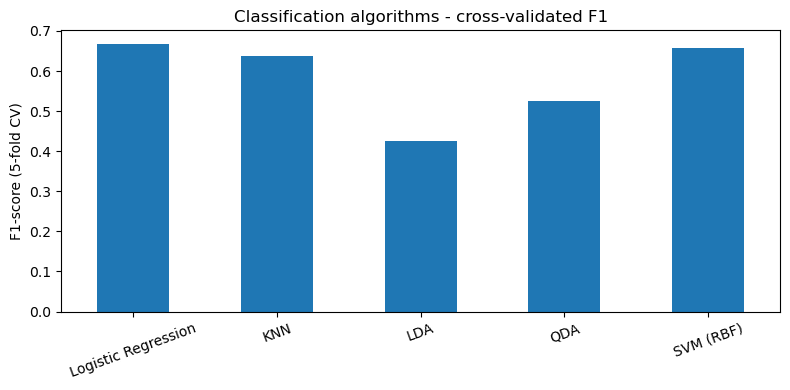

Logistic Regression    0.6681
KNN                    0.6377
LDA                    0.4249
QDA                    0.5251
SVM (RBF)              0.6565
Name: CV F1, dtype: float64

In [38]:
# Visual comparison of the cross-validated F1 of the algorithms
ax = pd.Series(cv_f1).plot.bar(figsize=(8, 4), rot=20)
ax.set_ylabel("F1-score (5-fold CV)")
ax.set_title("Classification algorithms - cross-validated F1")
plt.tight_layout()
plt.show()
pd.Series(cv_f1, name="CV F1").round(4)

Text(0, 0.5, 'ROC AUC (5-fold CV)')

Text(0.5, 1.0, 'Classification algorithms - cross-validated AUC')

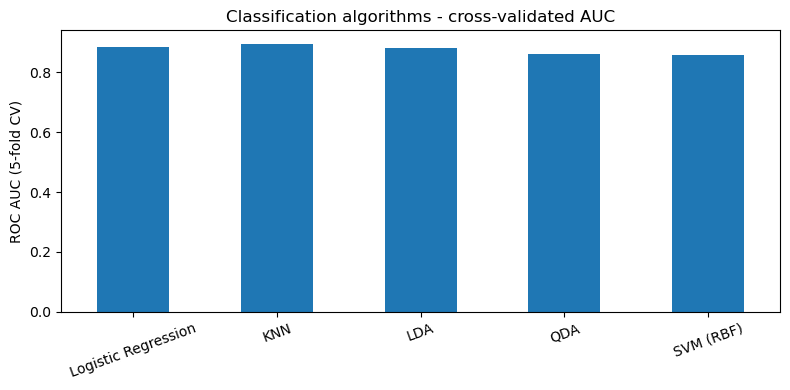

Logistic Regression    0.8866
KNN                    0.8960
LDA                    0.8818
QDA                    0.8632
SVM (RBF)              0.8582
Name: CV AUC, dtype: float64

In [39]:
# Visual comparison of the cross-validated AUC of the algorithms
ax = pd.Series(cv_auc).plot.bar(figsize=(8, 4), rot=20)
ax.set_ylabel("ROC AUC (5-fold CV)")
ax.set_title("Classification algorithms - cross-validated AUC")
plt.tight_layout()
plt.show()
pd.Series(cv_auc, name="CV AUC").round(4)

**Logistic Regression** (with balanced class weights) achieves the best cross-validated F1 (0.6681), followed by the RBF SVM (0.6565). The Gaussian generative models perform poorly in F1 (LDA 0.42, QDA 0.53), which is unsurprising: most of the selected features are binary dummies, as far from Gaussian as possible, so the normality assumption behind LDA/QDA is severely violated.

The AUC tells a complementary story: the ranking changes (KNN 0.896, Logistic 0.887, LDA 0.882), and in particular LDA scores a high AUC despite its very poor F1. This means LDA still separates the classes reasonably well (its scores rank purchasing sessions above non-purchasing ones), but its probability estimates are distorted by the violated Gaussian assumption, so its decisions at the default 0.5 threshold are poor. This is exactly the risk we anticipated when choosing F1 over AUC as the selection criterion: on imbalanced data, AUC can mask weak performance on the minority class.

Logistic Regression, second in AUC and first in F1, is therefore the most robust choice. Since `GridSearchCV` automatically refits the best configuration on the whole training set, **Logistic Regression** is selected as our final classifier.

## 2.5 Final evaluation on the test set

We now evaluate the selected classifier **on the provided test set** (used here for the first time): confusion matrix, per-class metrics and ROC curves.

Text(0.5, 1.0, 'Test Confusion Matrix')

Text(0.5, 1.0, 'Normalized by true class')

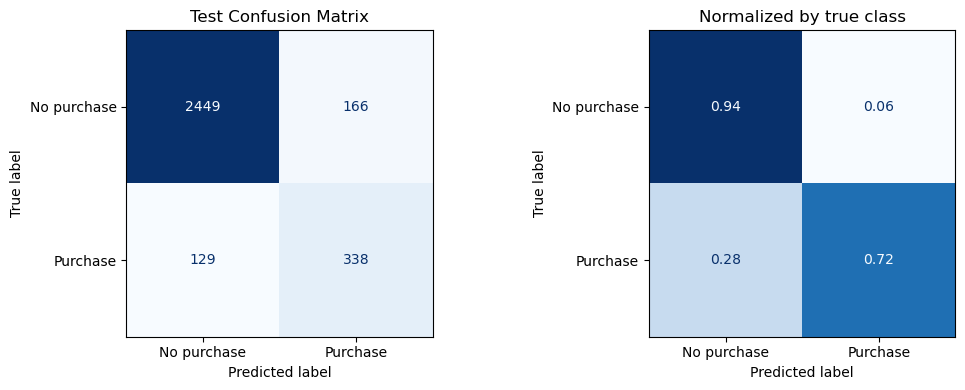

              precision    recall  f1-score   support

 No purchase       0.95      0.94      0.94      2615
    Purchase       0.67      0.72      0.70       467

    accuracy                           0.90      3082
   macro avg       0.81      0.83      0.82      3082
weighted avg       0.91      0.90      0.91      3082



In [40]:
y_pred = log_cv.predict(X_test_sel)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Test confusion matrix (as in Lab05_02)
ConfusionMatrixDisplay.from_estimator(
    log_cv, X_test_sel, y_test,
    display_labels=["No purchase", "Purchase"],
    colorbar=False, cmap="Blues", ax=ax[0])
ax[0].set_title("Test Confusion Matrix")

# Same matrix normalized by true class (recall of each class on the diagonal)
ConfusionMatrixDisplay.from_estimator(
    log_cv, X_test_sel, y_test,
    display_labels=["No purchase", "Purchase"],
    normalize="true", values_format=".2f",
    colorbar=False, cmap="Blues", ax=ax[1])
ax[1].set_title("Normalized by true class")

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["No purchase", "Purchase"]))

On the test set, the model correctly recognizes 94% of non-purchasing sessions and 72% of purchasing ones (recall), with a precision of 67% on the positive class, the expected trade-off given the 85/15 class imbalance, mitigated by `class_weight="balanced"`. The test F1 on the positive class (0.70) is fully consistent with the cross-validated F1 (0.6681), confirming that the model generalizes well with no sign of overfitting. The overall accuracy (0.90) is reported for completeness, but it is not the relevant metric here: a trivial classifier always predicting "no purchase" would already reach 85%.

## 2.6 Is `ExitRates` actually useful?
Forward selection already gave a first hint: `ExitRates` was **not** included in the best subset. To answer the question directly and fairly, we train the best model family (Logistic Regression, with the same hyperparameter grid) on **all the features including `ExitRates`** and on **all the features except `ExitRates`**, and compare the metrics both in cross-validation and on the test set.

In [41]:
# Logistic Regression on all the features, ExitRates included
log_all = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter=1000))]),
    {"model__C": [0.01, 0.1, 1, 10],
     "model__class_weight": [None, "balanced"]},
    cv=5, scoring="f1", n_jobs=-1)
log_all.fit(X_train, y_train)
print("With ExitRates:    best CV F1 = {:.4f}   {}".format(
    log_all.best_score_, log_all.best_params_))

# Logistic Regression on all the features except ExitRates
features_no_er = [f for f in X_train.columns if f != "ExitRates"]
log_no_er = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("model", LogisticRegression(max_iter=1000))]),
    {"model__C": [0.01, 0.1, 1, 10],
     "model__class_weight": [None, "balanced"]},
    cv=5, scoring="f1", n_jobs=-1)
log_no_er.fit(X_train[features_no_er], y_train)
print("Without ExitRates: best CV F1 = {:.4f}   {}".format(
    log_no_er.best_score_, log_no_er.best_params_))

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__class_weight': [None, 'balanced']},
             scoring='f1')

With ExitRates:    best CV F1 = 0.6010   {'model__C': 10, 'model__class_weight': 'balanced'}


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__class_weight': [None, 'balanced']},
             scoring='f1')

Without ExitRates: best CV F1 = 0.6050   {'model__C': 1, 'model__class_weight': 'balanced'}


In [42]:
# Compare the two models on the test set
y_pred_all = log_all.predict(X_test)
y_pred_no_er = log_no_er.predict(X_test[features_no_er])

comparison_er = pd.DataFrame({
    "with ExitRates": [
        accuracy_score(y_test, y_pred_all),
        precision_score(y_test, y_pred_all),
        recall_score(y_test, y_pred_all),
        f1_score(y_test, y_pred_all),
        roc_auc_score(y_test, log_all.predict_proba(X_test)[:, 1])],
    "without ExitRates": [
        accuracy_score(y_test, y_pred_no_er),
        precision_score(y_test, y_pred_no_er),
        recall_score(y_test, y_pred_no_er),
        f1_score(y_test, y_pred_no_er),
        roc_auc_score(y_test, log_no_er.predict_proba(X_test[features_no_er])[:, 1])],
}, index=["accuracy", "precision (pos)", "recall (pos)", "F1 (pos)", "AUC"])
comparison_er.round(4)

,with ExitRates,without ExitRates
accuracy,0.8527,0.8572
precision (pos),0.5088,0.5190
recall (pos),0.8073,0.7901
F1 (pos),0.6242,0.6265
AUC,0.9061,0.9071


The two models are essentially equivalent, the one without `ExitRates` is marginally better on every metric (CV F1: 0.6050 vs 0.6010; test F1: 0.6265 vs 0.6242; AUC: 0.9071 vs 0.9061). 

Together with the forward selection of Section 2.3, which never picked `ExitRates` (nor `BounceRates`), we can conclude that **a model built using the Exit Rate information is not better than a model built with the remaining features**. Once `PageValues` and the seasonality are known, the exit-rate information is redundant for predicting the purchase. 

This is consistent with the EDA (`ExitRates` is only mildly correlated with `Revenue`, r ≈ −0.2, and largely predictable from `BounceRates`) and with the fact that 30% of its values were themselves reconstructed from the other features, so they cannot add independent information by construction.

**A final remark:** both full-feature models (F1 ≈ 0.60–0.63) underperform the 4-feature model of Section 2.4 (test F1 = 0.70). The many rare dummy columns actively hurt the classifier rather than helping it, evidence that the feature selection removed noise, not signal.

# Request 3 - Clustering-based analysis

We now apply clustering algorithms to the data without using the class labels, and check whether the resulting groups correspond to the purchasing behavior. We work on the full standardized feature set (not the 4 features selected in Request 2, which were chosen using the labels and would contaminate an unsupervised analysis). 

For each algorithm, we turn the clustering into a classifier with a **majority-vote rule**: each cluster is labeled with the most frequent `Revenue` value among its training samples. Test samples are then assigned to the nearest cluster and receive its label, allowing us to compare the results with the supervised Logistic Regression of Request 2 (test F1 = 0.70) on the same test set.

In [43]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

# Standardize the full feature set.
# All the algorithms below are distance-based, so scaling is mandatory.
scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)
print("Clustering data:", X_train_std.shape)

Clustering data: (9248, 67)


## 3.1 Hierarchical clustering
We compute the linkage matrix with Ward's method and inspect the dendrogram to visualize the hierarchical structure of the data. Based on this, we apply `AgglomerativeClustering` to evaluate the silhouette score for different numbers of clusters.

<Figure size 1200x400 with 0 Axes>

Text(0.5, 1.0, 'Hierarchical clustering (Ward) - dendrogram, last 40 merges')

Text(0.5, 0, 'cluster size')

Text(0, 0.5, 'distance')

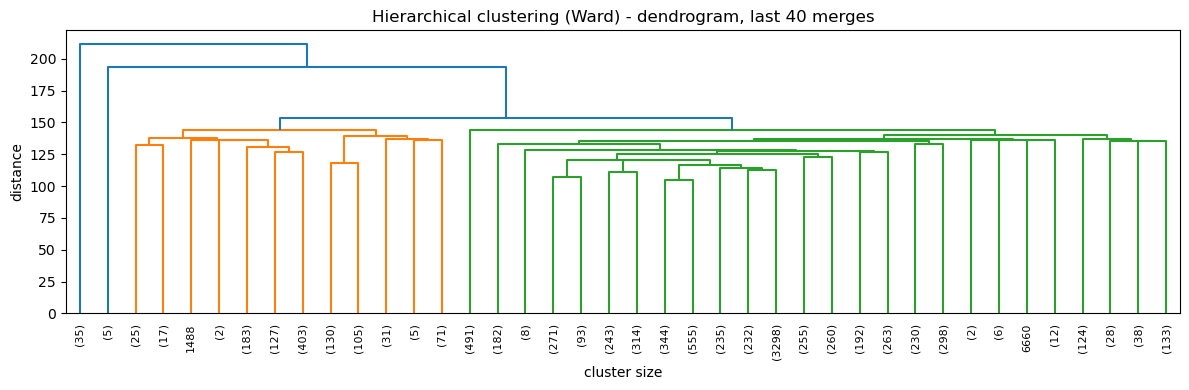

In [44]:
#Hierarchical clustering
Z = linkage(X_train_std, method="ward", metric="euclidean")
plt.figure(figsize=(12, 4))
dend = dendrogram(Z, truncate_mode="lastp", p=40, leaf_rotation=90)
plt.title("Hierarchical clustering (Ward) - dendrogram, last 40 merges")
plt.xlabel("cluster size")
plt.ylabel("distance")
plt.tight_layout()
plt.show()

In [45]:
# Cut the dendrogram at different numbers of clusters and
# compute the silhouette score for each cut
for nc in [2, 3, 4, 6, 8]:
    hier = AgglomerativeClustering(n_clusters=nc, linkage="ward")
    lab = hier.fit_predict(X_train_std)
    sil = silhouette_score(X_train_std, lab)
    sizes = np.bincount(lab)
    print(f"n_clusters = {nc}:  silhouette = {sil:.3f}   cluster sizes = {sizes}")

n_clusters = 2:  silhouette = 0.623   cluster sizes = [9213   35]
n_clusters = 3:  silhouette = 0.624   cluster sizes = [9208   35    5]
n_clusters = 4:  silhouette = 0.194   cluster sizes = [8108 1100    5   35]
n_clusters = 6:  silhouette = 0.092   cluster sizes = [7617  342  758   35  491    5]
n_clusters = 8:  silhouette = 0.106   cluster sizes = [ 758  323  107  235  491    5 7294   35]


The silhouette score is highest at `n=2-3` (≈0.62), but this is **misleading**: looking at the cluster sizes, these solutions simply isolate a handful of outliers (35, then 5 points) from one giant cluster of ~9200 samples. A high silhouette here reflects **outlier separation, not meaningful structure**, no cut of the dendrogram produces balanced, interpretable groups. We keep `n=3` for the evaluation below, mainly for comparability with **K-Means**.

## 3.2 K-Means: choosing the number of clusters

We run K-Means for $k = 2, \dots, 12$ and use the **elbow method** (Within-Cluster Sum of Squares, WSS) together with the **silhouette score** to choose the optimal number of clusters k.

  File "C:\Users\giaco\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\giaco\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\giaco\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\giaco\anaconda3\Lib\subprocess.

Text(0.5, 0, 'k')

Text(0, 0.5, 'WSS')

Text(0.5, 1.0, 'Elbow method')

Text(0.5, 0, 'k')

Text(0, 0.5, 'silhouette score')

Text(0.5, 1.0, 'Silhouette score')

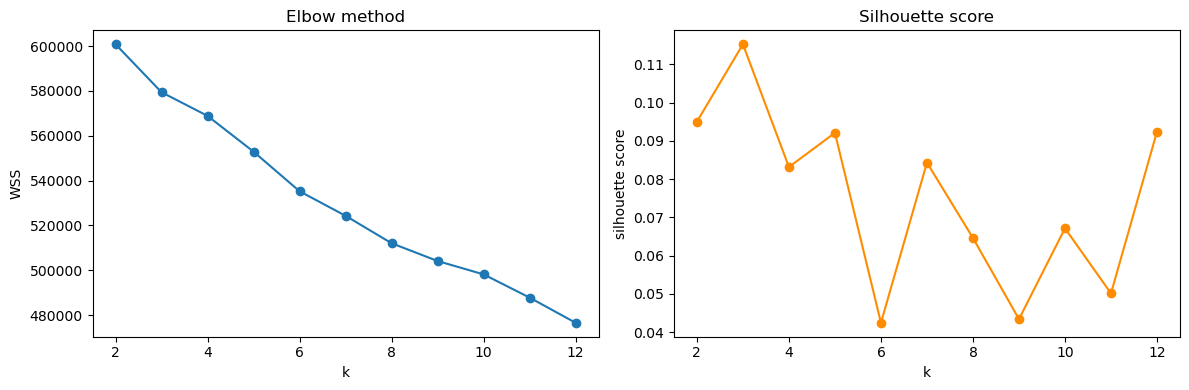

In [46]:
ks = range(2, 13)
wss = []
silhouettes = []
kmeans_models = {}

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X_train_std)
    wss.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_std, labels))
    kmeans_models[k] = km

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), wss, marker="o")
ax[0].set_xlabel("k"); ax[0].set_ylabel("WSS")
ax[0].set_title("Elbow method")
ax[1].plot(list(ks), silhouettes, marker="o", color="darkorange")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette score")
ax[1].set_title("Silhouette score")
plt.tight_layout()
plt.show()

PCA(n_components=2)

Explained variance ratio (first 2 PCs): [0.054 0.044] -> total: 9.9%
k with the best silhouette: 3


Text(0.5, 1.0, 'K-Means, k = 2')

Text(0.5, 1.0, 'K-Means, k = 3 (best silhouette)')

Text(0.5, 1.0, 'True labels (Revenue)')

...

Text(0, 0.5, 'PC 2')

Text(0.5, 0, 'PC 1')

Text(0, 0.5, 'PC 2')

Text(0.5, 0, 'PC 1')

Text(0, 0.5, 'PC 2')

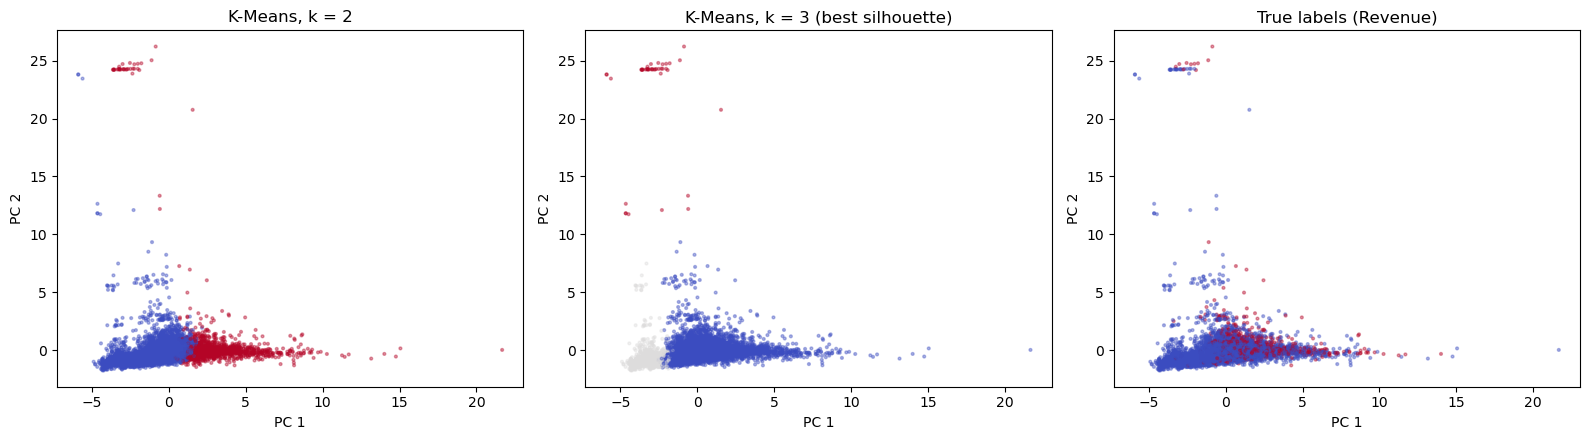

In [47]:
# Visualize the K-Means clusters in the space of the first two
# principal components, and compare with the true labels
pca = PCA(n_components=2)
pca.fit(X_train_std)
X_pca = pca.transform(X_train_std)
print("Explained variance ratio (first 2 PCs):",
      pca.explained_variance_ratio_.round(3),
      "-> total: {:.1%}".format(pca.explained_variance_ratio_.sum()))

best_k = list(ks)[int(np.argmax(silhouettes))]
print("k with the best silhouette:", best_k)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_models[2].labels_,
              s=4, alpha=0.4, cmap="coolwarm")
ax[0].set_title("K-Means, k = 2")
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_models[best_k].labels_,
              s=4, alpha=0.4, cmap="coolwarm")
ax[1].set_title(f"K-Means, k = {best_k} (best silhouette)")
ax[2].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, s=4, alpha=0.4, cmap="coolwarm")
ax[2].set_title("True labels (Revenue)")
for a in ax:
    a.set_xlabel("PC 1"); a.set_ylabel("PC 2")
plt.tight_layout()
plt.show()

The first two principal components explain only **9.9%** of the total variance, so this 2D view is necessarily partial. Still, it is informative: in the rightmost panel, the true `Revenue` labels show substantial overlap between the two classes: purchasing sessions do not form a visually separate region. The **K-Means** clusters (left and center panels) do not align with this distinction either.

## 3.3 DBSCAN

**DBSCAN** requires two hyperparameters: `min_samples` (set to 10) and `eps`, which we choose from the **k-distance plot**. This plot shows the distance of each point to its 10th nearest neighbor, sorted in increasing order. The "knee" of this curve marks the transition between points in dense regions and outliers.

NearestNeighbors(n_neighbors=10)

<Figure size 800x350 with 0 Axes>

Text(0.5, 0, 'points sorted by distance')

Text(0, 0.5, 'distance to the 10-th neighbor')

Text(0.5, 1.0, 'k-distance plot (subsample)')

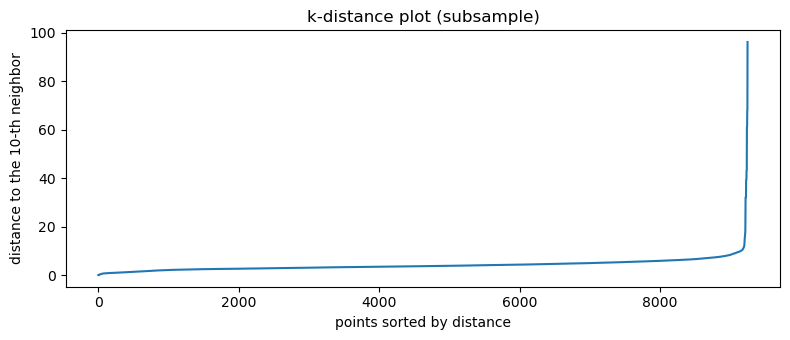

In [48]:
from sklearn.neighbors import NearestNeighbors

k = 10
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_train_std)
dists, _ = nn.kneighbors(X_train_std)
kdist = np.sort(dists[:, -1])

plt.figure(figsize=(8, 3.5))
plt.plot(kdist)
plt.xlabel("points sorted by distance")
plt.ylabel(f"distance to the {k}-th neighbor")
plt.title("k-distance plot (subsample)")
plt.tight_layout()
plt.show()

In [49]:
# Try a few eps values around the knee of the k-distance plot above
for eps in [2.5, 3.0, 4.5, 6.0, 7.0, 8.0, 10.0, 12.0]:
    db = DBSCAN(eps=eps, min_samples=k)
    db.fit(X_train_std )
    lab = db.labels_
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    noise = np.mean(lab == -1)
    print(f"eps = {eps:.1f}:  clusters = {n_clusters:3d}   noise = {noise:5.1%}")

DBSCAN(eps=2.5, min_samples=10)

eps = 2.5:  clusters =  71   noise = 73.1%


DBSCAN(eps=3.0, min_samples=10)

eps = 3.0:  clusters =  44   noise = 55.2%


DBSCAN(eps=4.5, min_samples=10)

...

eps = 8.0:  clusters =  16   noise =  1.7%


DBSCAN(eps=10.0, min_samples=10)

eps = 10.0:  clusters =  11   noise =  0.6%


DBSCAN(eps=12.0, min_samples=10)

eps = 12.0:  clusters =   9   noise =  0.5%


In [50]:
# eps = 6 is chosen at the knee of the k-distance plot above, where the
# noise fraction stops dropping sharply and starts flattening out
db = DBSCAN(eps=6.0, min_samples=10)
db_labels = db.fit_predict(X_train_std)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_frac = np.mean(db_labels == -1)
sizes = np.bincount(db_labels[db_labels >= 0])
print("DBSCAN (eps=6): {} clusters, {:.1%} noise".format(n_clusters, noise_frac))
print("Cluster sizes:", np.sort(sizes)[::-1])

DBSCAN (eps=6): 19 clusters, 6.0% noise
Cluster sizes: [7283  226  165  162  160  113  110   92   86   69   40   37   33   31
   28   21   17   11   10]


We choose `eps = 6.0`: the noise fraction drops sharply up to this point (from 73.1% at `eps = 2.5` down to 6.0%) and then flattens much more slowly (3.0% at `eps = 7.0`, 0.6% at `eps = 10.0`), meaning larger values mostly absorb true outliers into ever-bigger clusters rather than revealing genuine structure.

**DBSCAN** produces a very different result: instead of 1-2 dominant clusters, it splits the data into up to 19 smaller groups (from 7283 down to 10 points). This suggests that with 67 features, the notion of "density" used by **DBSCAN** becomes less effective at separating a few large regions, unlike what typically happens with fewer dimensions.

## 3.4 From clusters to a classifier

We turn a clustering into a classifier with the **majority-vote rule**: each cluster is labeled with the most frequent `Revenue` value of its training samples; a test sample gets the label of its nearest cluster (for K-Means, the nearest centroid). We evaluate K-Means with k=2 and with the best-silhouette k (chosen in Section 3.2), plus the hierarchical solution and DBSCAN.

In [51]:
# Turn each clustering into a classifier with the majority-vote rule:
# each cluster takes the most frequent Revenue label of its training samples,
# and test samples receive the label of the cluster they are assigned to
def majority_mapping(y_true, clusters):
    mapping = {}
    for c in np.unique(clusters):
        labels, counts = np.unique(y_true[clusters == c], return_counts=True)
        mapping[c] = labels[np.argmax(counts)]
    return mapping

In [52]:
f1_per_k = {}
for k in [2, best_k]:
    km = kmeans_models[k]
    mapping = majority_mapping(y_train.to_numpy(), km.labels_)
    test_clusters = km.predict(X_test_std)
    y_pred_km = np.array([mapping[c] for c in test_clusters])
    f1_per_k[k] = f1_score(y_test, y_pred_km)
    print("k = {:2d}:  test F1 = {:.4f}   clusters mapped to 'Purchase': {}".format(
        k, f1_per_k[k], sum(v == 1 for v in mapping.values())))

k =  2:  test F1 = 0.0000   clusters mapped to 'Purchase': 0
k =  3:  test F1 = 0.0000   clusters mapped to 'Purchase': 0


Both **K-Means** solutions (`k=2` and `k=3`) yield a test F1 of **0**: the **majority-vote rule** maps every cluster to "No purchase". This is explained directly by the purchase rate inside each cluster, shown below.

<Axes: >

Text(0.5, 0, 'cluster')

Text(0, 0.5, 'purchase rate')

Text(0.5, 1.0, 'Purchase rate inside each K-Means cluster (k = 3)')

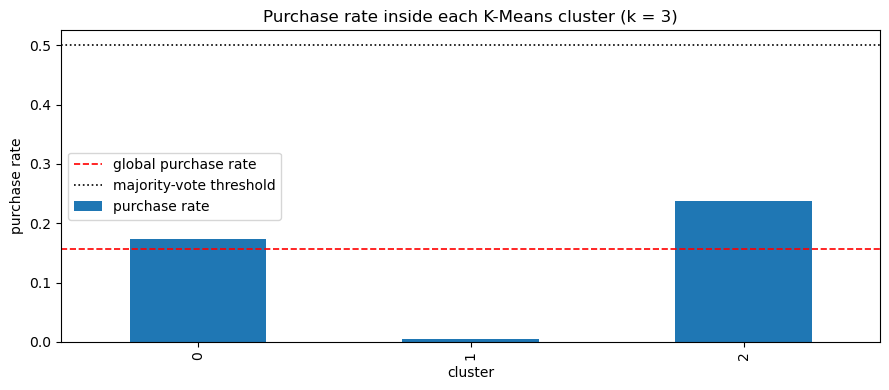

,size,purchase rate
0,8251,0.173
1,955,0.004
2,42,0.238


In [53]:
km_best = kmeans_models[best_k]
comp = pd.DataFrame({
    "size": pd.Series(km_best.labels_).value_counts().sort_index(),
    "purchase rate": pd.Series(y_train.values).groupby(km_best.labels_).mean(),
})
fig, ax = plt.subplots(figsize=(9, 4))
comp["purchase rate"].plot.bar(ax=ax)
ax.axhline(y_train.mean(), color="red", ls="--", lw=1.2, label="global purchase rate")
ax.axhline(0.5, color="black", ls=":", lw=1.2, label="majority-vote threshold")
ax.set_xlabel("cluster"); ax.set_ylabel("purchase rate")
ax.set_title("Purchase rate inside each K-Means cluster (k = {})".format(best_k))
ax.legend()
plt.tight_layout()
plt.show()
comp.round(3)

None of the three **K-Means** clusters reaches a purchase rate above 50% (the highest, cluster 2, is only 23.8%, on just 42 points): all bars sit below the majority-vote threshold (dashed black line). Consequently, every cluster is labeled `"No purchase"`, and the resulting classifier never predicts a sale. The clusters mostly reflect other sources of variance in the data, not the purchase outcome.

In [54]:
from sklearn.metrics import pairwise_distances_argmin

# Hierarchical clustering as a classifier: test samples are assigned to the
# cluster with the nearest centroid (AgglomerativeClustering has no predict)
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = hier.fit_predict(X_train_std)

centroids = np.vstack([X_train_std[hier_labels == c].mean(axis=0)
                       for c in np.unique(hier_labels)])
mapping_h = majority_mapping(y_train.to_numpy(), hier_labels)
test_clusters_h = pairwise_distances_argmin(X_test_std, centroids)
y_pred_hier = np.array([mapping_h[c] for c in test_clusters_h])
f1_hier = f1_score(y_test, y_pred_hier)
print("Hierarchical (n=3): test F1 = {:.4f}".format(f1_hier))

Hierarchical (n=3): test F1 = 0.0000


**Hierarchical clustering** yields the same outcome: test F1 = **0**. This is expected, since Section 3.1 already showed its `n=2-3` solution to be dominated by one giant cluster plus a few outliers. This indicates the same lack of alignment with `Revenue` as **K-Means**.

In [55]:
def tot_purity(y_true, clusters):
    """Fraction of samples sharing the majority label of their cluster (Lab06)."""
    total = 0
    for c in np.unique(clusters):
        _, counts = np.unique(y_true[clusters == c], return_counts=True)
        total += counts.max()
    return total / len(y_true)

print("Purity — KMeans k={}: {:.3f} | Hierarchical n=3: {:.3f} | baseline (majority class): {:.3f}".format(
    best_k,
    tot_purity(y_train.to_numpy(), km_best.labels_),
    tot_purity(y_train.to_numpy(), hier_labels),
    max(np.mean(y_train), 1 - np.mean(y_train))))

Purity — KMeans k=3: 0.844 | Hierarchical n=3: 0.844 | baseline (majority class): 0.844


The **purity** of both clustering solutions (**0.844**) is indistinguishable from the **majority-class baseline** (0.844, which corresponds to always predicting `"No purchase"`). This confirms quantitatively what the purchase-rate plot showed visually: the clusters add no information about the target beyond the class imbalance itself.

In [56]:
from sklearn.neighbors import KNeighborsClassifier

# DBSCAN has no predict/centroids: test points are assigned to the cluster
# of their nearest labeled training point (1-NN on the non-noise points)
core_mask = db_labels != -1
nn1 = KNeighborsClassifier(n_neighbors=1)
nn1.fit(X_train_std[core_mask], db_labels[core_mask])
test_clusters_db = nn1.predict(X_test_std)

mapping_db = majority_mapping(y_train.to_numpy()[core_mask], db_labels[core_mask])
y_pred_db = np.array([mapping_db[c] for c in test_clusters_db])
f1_db = f1_score(y_test, y_pred_db)

purity_db = tot_purity(y_train.to_numpy()[core_mask], db_labels[core_mask])
print("DBSCAN: test F1 = {:.4f}, purity (on non-noise points) = {:.3f}".format(f1_db, purity_db))

KNeighborsClassifier(n_neighbors=1)

DBSCAN: test F1 = 0.0000, purity (on non-noise points) = 0.847


**DBSCAN** gives the same result (test F1 = **0**, **purity** 0.847 ≈ baseline), despite finding a completely different cluster structure (19 small dense groups instead of 2-3 large ones). This strengthens the conclusion: it is not a property of one specific algorithm's bias, but of the data itself. Purchasing sessions are not geometrically separable from non-purchasing ones, regardless of how the space is partitioned.

In [57]:
final_r3 = pd.Series({
    "Logistic Regression (Request 2)": 0.70,   # test F1 from Section 2.5
    "K-Means (best k, majority vote)": max(f1_per_k.values()),
    "Hierarchical (n=3, majority vote)": f1_hier,
    "DBSCAN (eps=6, majority vote)": f1_db,
}, name="test F1")
final_r3.round(4)

Logistic Regression (Request 2)      0.7
K-Means (best k, majority vote)      0.0
Hierarchical (n=3, majority vote)    0.0
DBSCAN (eps=6, majority vote)        0.0
Name: test F1, dtype: float64

### Summary of Request 3

All three clustering-based classifiers collapse to a trivial `"always no purchase"` prediction (test F1 = **0**), far below the supervised **Logistic Regression** (0.70). The purchase rate inside every cluster (for **K-Means**, hierarchical clustering, and **DBSCAN** alike) never exceeds 24%, always remaining below the 50% majority-vote threshold. Consequently, the **purity** of every clustering solution (0.844 to 0.847) is indistinguishable from the **majority-class baseline** (0.844). 

This is consistent with the **PCA** projection, which already showed the two classes overlapping in the principal-component space. The conclusion is not a failure of the algorithms: it shows that `Revenue` encodes information about actual user behavior that cannot be recovered from the geometric structure of the features alone. Supervision (using the labels during training, as in Request 2) is essential for this task, and no unsupervised method can substitute for it here.